# Predicción de Altiplanos a partir de Rásters (v2) — Regresión NO Espacializada

## Introducción

**Qué se busca:** en `01_clustering_altiplanos_v2.ipynb` y
`02_clustering_espacial_altiplanos_v2.ipynb` se trabajó con los 491 altiplanos ya
delimitados a mano, tipificándolos según su morfometría. Aquí se cambia de pregunta: en vez
de tipificar altiplanos ya conocidos, se busca **predecir, a nivel de PÍXEL, si un punto
cualquiera del área de estudio es o no un altiplano**, usando como predictores un conjunto
de capas ráster derivadas del terreno (altitud, pendiente, relieve y variantes de "residuo"
de altitud respecto a la media/mínimo/máximo en distintas ventanas móviles).

Esta es una **regresión NO espacializada**: cada píxel se trata como una observación
independiente descrita únicamente por sus propios valores de altitud/pendiente/relieve, sin
considerar la ubicación del píxel ni la de sus vecinos.

**Método del libro utilizado:** notebook `04_GLMPhyton` del libro *Análisis Geoespacial*
(Aristizábal), sección de **Regresión Logística**. La variable respuesta es binaria (1 =
altiplano, 0 = no altiplano), así que el modelo correcto de la familia de Modelos Lineales
Generalizados (GLM) es la regresión logística. Se ajusta con `statsmodels.Logit` (resumen
interpretable, Pseudo R²) y se evalúa con matriz de confusión y curva ROC.

**Nota sobre las capas:** por instrucción del usuario, `DEM_NA_50.tif` se llama **Altitud**
y `Slp_NA_50.tif` se llama **Pendiente** en todos los gráficos y tablas.

**Cambios respecto a la versión anterior de este notebook:**
- Se agregó una sección de exploración de datos dedicada (histogramas de predictores clave,
  área cubierta en km², N de píxeles válidos/excluidos con su porcentaje).
- La matriz de confusión incluye el panel **normalizado por fila** (consolidado desde
  `03b_regresion_no_espacial_matriz_corregida.ipynb`).
- **Las métricas ahora se reportan enfocadas en la clase Altiplano** (recall, precisión, F1
  de Altiplano primero y más prominente), no en "No altiplano" — por instrucción explícita
  del usuario, ya que el objetivo sustantivo del trabajo es identificar altiplanos, no
  descartarlos.
- El histograma de balance de clases ahora muestra explícitamente el desbalance por
  **cantidad total** (barras 0 vs. 1) además de por Altitud/Pendiente/Relieve.

*(Se exploró también un segundo modelo con enlace cloglog en una iteración intermedia de
este notebook; se descartó por instrucción del usuario — ver `CONTEXTO_PROYECTO_v2.md`,
sección 4b, para el razonamiento completo y los resultados de esa comparación.)*


## [1] Configuración e importación de librerías


In [1]:
# --- Librerías estándar ---
import os        # rutas y carpetas
import time      # medir tiempos de ejecución (este notebook procesa ~25 millones de píxeles)
import warnings  # silenciar avisos no críticos

# --- Datos y numérico ---
import numpy as np   # arreglos: aquí las capas ráster se manejan como matrices 2D
import pandas as pd  # tabla píxel×variable para ajustar el modelo
import rasterio      # leer/escribir GeoTIFF (rásters georreferenciados)
from rasterio.warp import reproject, Resampling      # remuestrear una capa a otra grilla
from rasterio.transform import array_bounds          # límites geográficos de una grilla (para mapear)
import geopandas as gpd  # leer los polígonos de altiplano (vectorial) para superponerlos

import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelo estadístico ---
import statsmodels.api as sm                                      # GLM/Logit con resumen estadístico completo
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF (colinealidad)

# --- Utilidades de ML: estandarizar, partir train/test y métricas de clasificación ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
)

warnings.filterwarnings("ignore")  # oculta warnings (p. ej. de cuasi-separación de statsmodels)

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "03_regresion_no_espacial_raster_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42          # reproducibilidad (muestreo y partición train/test)
N_MUESTRA = 300_000   # nº de píxeles que se muestrean para ajustar el modelo (de ~25 millones)

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")

Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\03_regresion_no_espacial_raster_v2


## [2] Cargar el DEM como grilla de referencia y máscara de validez

El DEM (`DEM_NA_50.tif`, llamado **Altitud**) define la extensión de trabajo. Sus píxeles
"NoData" delimitan el área fuera de la zona de estudio; cualquier capa que tenga valores
donde el DEM tiene NoData debe ignorarse ahí también.


In [2]:
t_inicio = time.time()  # marca de tiempo inicial

# Abre el DEM (modelo de elevación) que define la grilla de referencia de todo el análisis.
with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)   # read(1) = primera banda -> matriz 2D de altitud
    dem_nodata = src.nodata                    # valor que marca "sin dato" (fuera del área)
    ref_transform = src.transform              # transform: mapea (fila, col) -> (x, y) geográficos
    ref_crs = src.crs                          # sistema de coordenadas (EPSG:32618)
    ref_shape = (src.height, src.width)        # (filas, columnas) de la grilla

mascara_dem_valida = altitud != dem_nodata  # matriz booleana: True donde hay dato válido

print(f"Dimensiones de la grilla de referencia (Altitud): {ref_shape[1]} columnas x {ref_shape[0]} filas")
print(f"CRS: {ref_crs}")
# .sum() sobre un booleano cuenta los True; .size = total de celdas.
print(f"Pixeles validos en el DEM: {mascara_dem_valida.sum():,} de {mascara_dem_valida.size:,} "
      f"({100*mascara_dem_valida.sum()/mascara_dem_valida.size:.1f}%)")
print(f"Rango de Altitud: {altitud[mascara_dem_valida].min():.0f} - {altitud[mascara_dem_valida].max():.0f} m")

Dimensiones de la grilla de referencia (Altitud): 6084 columnas x 8276 filas
CRS: EPSG:32618
Pixeles validos en el DEM: 24,814,468 de 50,351,184 (49.3%)
Rango de Altitud: 14 - 3979 m


## [3] Variable respuesta: alinear `Altiplanos.tif` a la grilla del DEM

`Altiplanos.tif` (valor 1 = altiplano) no comparte exactamente la misma grilla que el DEM:
mismo CRS y resolución (50 m) pero una extensión más pequeña y un origen desalineado por
una fracción de píxel. Se remuestrea a la grilla EXACTA del DEM con
`rasterio.warp.reproject` usando interpolación **vecino más cercano** (la única apropiada
para una máscara categórica 0/1).


In [3]:
# Carga la máscara de altiplanos (1 = altiplano). No comparte exactamente la grilla del DEM.
with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs
    print(f"Altiplanos.tif - shape original: {src.width}x{src.height}  (Altitud: {ref_shape[1]}x{ref_shape[0]})")

# reproject: remuestrea la máscara a la grilla EXACTA del DEM (mismo shape/transform).
# Resampling.nearest (vecino más cercano) = único método correcto para una máscara categórica 0/1.
altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)  # matriz destino, misma forma que el DEM
reproject(
    source=altiplano_original, destination=altiplano_alineado,
    src_transform=altiplano_transform, src_crs=altiplano_crs,      # grilla origen
    dst_transform=ref_transform, dst_crs=ref_crs,                  # grilla destino (la del DEM)
    resampling=Resampling.nearest, src_nodata=altiplano_nodata, dst_nodata=0,
)
# np.unique(..., return_counts=True) = valores distintos y cuántas veces aparecen (0 y 1).
print(f"\nAltiplanos alineado a la grilla del DEM. Valores unicos: {np.unique(altiplano_alineado, return_counts=True)}")

Altiplanos.tif - shape original: 5856x7601  (Altitud: 6084x8276)



Altiplanos alineado a la grilla del DEM. Valores unicos: (array([0, 1], dtype=uint8), array([46604846,  3746338]))


## [4] Cargar todas las capas predictoras

Se construye una **máscara de validez combinada**: válido solo donde el DEM Y **todas** las
capas predictoras tienen datos (algunas ventanas móviles grandes tienen NoData en un borde
más ancho que el propio DEM). `Relieve_3`, `Relieve_10` y `DifMedia_5_10` del listado
original de archivos se excluyen por ser combinaciones lineales exactas de otras variables
ya incluidas (ver sección [8] de VIF).


In [4]:
# Diccionario {nombre lógico: archivo .tif} de los 18 predictores geomorfométricos.
predictores_archivos = {
    "Altitud": "DEM_NA_50.tif",
    "Pendiente": "Slp_NA_50.tif",
    "Relieve_5": "Rel_NA_5.tif",
    "ResidMedia_5": "Resta_Alt_NA_Alt_mean_5.tif",
    "ResidMedia_10": "Resta_Alt_NA_Alt_mean_10.tif",
    "ResidMin_3": "Resta_Alt_NA_Alt_min_3.tif",
    "ResidMin_10": "Resta_Alt_NA_Alt_min_10.tif",
    "ResidMin_50": "Resta_Alt_NA_Alt_min_50.tif",
    "ResidMin_100": "Resta_Alt_NA_Alt_min_100.tif",
    "ResidMax_3": "Resta_Alt_max_3_Alt_NA.tif",
    "ResidMax_10": "Resta_Alt_max_10_Alt_NA.tif",
    "ResidMax_50": "Resta_Alt_max_50_Alt_NA.tif",
    "ResidMax_100": "Resta_Alt_max_100_Alt_NA.tif",
    "DifMedia_3_10": "Resta_Alt_mean_3_10.tif",
    "PendResidMedia_5": "Slp_Resta_Alt_NA_Alt_mean_5.tif",
    "PendResidMedia_10": "Slp_Resta_Alt_NA_Alt_mean_10.tif",
    "PendDifMedia_3_10": "Slp_Resta_Alt_mean_3_10.tif",
    "PendDifMedia_5_10": "Slp_Resta_Alt_mean_5_10.tif",
}

datos = {}                                    # guardará cada banda leída {nombre: matriz}
mascara_valida = mascara_dem_valida.copy()    # se irá restringiendo con cada capa (AND acumulado)

for nombre, archivo in predictores_archivos.items():
    with rasterio.open(f"{CARPETA_RASTER}\\{archivo}") as src:
        # Verifica que la capa comparta grilla con el DEM (mismo transform con tolerancia 1e-3, y mismo shape).
        coincide = all(abs(a - b) < 1e-3 for a, b in zip(src.transform, ref_transform)) and \
            (src.height, src.width) == ref_shape
        if not coincide:
            raise ValueError(f"{archivo} no coincide con la grilla de referencia (Altitud)")

        banda = src.read(1).astype(np.float32)
        nod = src.nodata
        # El NoData puede venir como NaN o como un valor centinela; se detecta cada caso.
        if nod is not None and np.isnan(nod):
            valido_capa = ~np.isnan(banda)
        elif nod is not None:
            valido_capa = banda != nod
        else:
            valido_capa = np.ones_like(banda, dtype=bool)

    datos[nombre] = banda
    mascara_valida &= valido_capa   # &= : un píxel es válido solo si lo es en TODAS las capas

variables_predictoras = list(predictores_archivos.keys())
print(f"{len(predictores_archivos)} capas predictoras cargadas: {variables_predictoras}")
print(f"\nMascara de validez combinada (DEM + {len(predictores_archivos)} predictores): "
      f"{mascara_valida.sum():,} pixeles ({100*mascara_valida.sum()/mascara_valida.size:.1f}% del area total)")

18 capas predictoras cargadas: ['Altitud', 'Pendiente', 'Relieve_5', 'ResidMedia_5', 'ResidMedia_10', 'ResidMin_3', 'ResidMin_10', 'ResidMin_50', 'ResidMin_100', 'ResidMax_3', 'ResidMax_10', 'ResidMax_50', 'ResidMax_100', 'DifMedia_3_10', 'PendResidMedia_5', 'PendResidMedia_10', 'PendDifMedia_3_10', 'PendDifMedia_5_10']

Mascara de validez combinada (DEM + 18 predictores): 24,783,966 pixeles (49.2% del area total)


## [5] Construir la tabla de píxeles

Se convierten las capas ráster (matrices 2D) en una tabla donde cada FILA es un píxel
válido y cada COLUMNA es una variable — la unidad de análisis pasa de ser un polígono
(notebooks 01/02) a ser un píxel de 50x50 m.


In [5]:
# flatnonzero: índices (1D) de los píxeles válidos dentro de la matriz aplanada.
idx_validos = np.flatnonzero(mascara_valida)
y_altiplano = (altiplano_alineado == 1) & mascara_valida   # respuesta 0/1 solo en píxeles válidos

# Construye la tabla: una fila por píxel válido, una columna por predictor.
# banda.ravel()[idx_validos] aplana cada capa y toma solo los píxeles válidos.
tabla = pd.DataFrame({nombre: banda.ravel()[idx_validos] for nombre, banda in datos.items()})
tabla["Altiplano"] = y_altiplano.ravel()[idx_validos].astype(int)   # columna respuesta (0/1)

# memory_usage(deep=True).sum()/1e9 = memoria de la tabla en GB.
print(f"Tabla de pixeles: {tabla.shape[0]:,} filas x {tabla.shape[1]} columnas "
      f"({tabla.memory_usage(deep=True).sum()/1e9:.2f} GB en memoria)")
print(f"Tiempo transcurrido: {time.time()-t_inicio:.1f} s")

Tabla de pixeles: 24,783,966 filas x 19 columnas (1.98 GB en memoria)
Tiempo transcurrido: 10.2 s


## [6] Exploración de datos

**Qué se busca:** antes de ajustar cualquier modelo, describir la calidad y forma de los
datos de entrada: cuántos píxeles se usan y cuántos se excluyeron (y por qué), el área que
representa la muestra válida, y el **desbalance de clases** — tanto en cantidad total como
en la distribución de los predictores clave (Altitud, Pendiente, Relieve) por clase.


In [6]:
# Conteos de píxeles para el reporte de exploración (N total, válidos, excluidos).
n_total = mascara_valida.size
n_dem_validos = mascara_dem_valida.sum()
n_final_validos = mascara_valida.sum()
n_excluidos_por_predictores = n_dem_validos - n_final_validos
resolucion_m = abs(ref_transform.a)  # 50 m -> transform.a es el tamaño de píxel en X

print("N (numero de observaciones = pixeles):")
print(f"  Total de pixeles en la grilla:                  {n_total:,}")
print(f"  Validos segun el DEM:                            {n_dem_validos:,} ({100*n_dem_validos/n_total:.1f}%)")
print(f"  Excluidos ademas por NoData en algun predictor:  {n_excluidos_por_predictores:,} "
      f"({100*n_excluidos_por_predictores/n_total:.1f}% del total)")
print(f"  Validos FINALES (usados en el analisis):          {n_final_validos:,} ({100*n_final_validos/n_total:.1f}%)")

# Área = nº de píxeles × (lado del píxel)²; / 1e6 pasa de m² a km².
area_total_km2 = n_total * (resolucion_m ** 2) / 1e6
area_valida_km2 = n_final_validos * (resolucion_m ** 2) / 1e6
print(f"\nArea cubierta por la grilla completa: {area_total_km2:,.1f} km2 (resolucion {resolucion_m:.0f} m)")
print(f"Area cubierta por los pixeles validos usados en el modelo: {area_valida_km2:,.1f} km2")

conteo = tabla["Altiplano"].value_counts()   # cuántos 0 y cuántos 1 (balance de clases)
print("\nDistribucion de la variable respuesta (balance de clases):")
print(conteo)
print(f"Proporcion de pixeles Altiplano=1: {tabla['Altiplano'].mean()*100:.1f}% "
      f"(desbalance de clases: la clase minoritaria es Altiplano)")

N (numero de observaciones = pixeles):
  Total de pixeles en la grilla:                  50,351,184
  Validos segun el DEM:                            24,814,468 (49.3%)
  Excluidos ademas por NoData en algun predictor:  30,502 (0.1% del total)
  Validos FINALES (usados en el analisis):          24,783,966 (49.2%)

Area cubierta por la grilla completa: 125,878.0 km2 (resolucion 50 m)
Area cubierta por los pixeles validos usados en el modelo: 61,959.9 km2

Distribucion de la variable respuesta (balance de clases):
Altiplano
0    21037628
1     3746338
Name: count, dtype: int64
Proporcion de pixeles Altiplano=1: 15.1% (desbalance de clases: la clase minoritaria es Altiplano)


In [7]:
# Estadísticas descriptivas de los 18 predictores (última expresión -> se muestra como tabla).
tabla[variables_predictoras].describe().T

,count,mean,std,min,25%,50%,75%,max
Altitud,24783966.0,1234.627197,752.470276,14.000000,599.000000,1059.000000,1813.000000,3979.000000
Pendiente,24783966.0,18.635334,9.648067,0.000000,10.961411,17.716219,25.510118,86.237625
Relieve_5,24783966.0,153.334641,78.530083,0.000000,90.000000,140.000000,204.000000,2162.000000
ResidMedia_5,24783966.0,0.001161,19.196657,-594.432129,-12.185181,-0.641968,12.036987,957.765381
ResidMedia_10,24783966.0,-0.015681,36.651653,-403.741333,-22.205078,-1.374281,21.548889,1474.958984
ResidMin_3,24783966.0,47.619080,29.628935,0.000000,24.000000,43.000000,67.000000,1943.000000
ResidMin_10,24783966.0,127.147125,84.114449,0.000000,59.000000,110.000000,180.000000,2162.000000
ResidMin_50,24783966.0,345.880615,240.534546,0.000000,153.000000,287.000000,486.000000,2488.000000
ResidMin_100,24783966.0,492.725800,338.351318,0.000000,221.000000,410.000000,689.000000,2837.000000
ResidMax_3,24783966.0,49.127792,29.026569,0.000000,27.000000,45.000000,67.000000,1943.000000


**Histograma del desbalance de clases:** panel 1 muestra el conteo total de píxeles
No-altiplano vs. Altiplano (la asimetría ~85%/15% que motiva usar `class_weight="balanced"`
en `05_modelo_jerarquico_cordilleras_v2.ipynb`). Los paneles 2-4 muestran cómo se
distribuyen Altitud, Pendiente y Relieve_5 SEPARADAS por clase — si las distribuciones se
solapan mucho, el problema es más difícil; si están bien separadas (como se ve abajo), es
coherente con el AUC alto que se obtiene más adelante. Por costo computacional, los
histogramas de Altitud/Pendiente/Relieve usan una muestra aleatoria de 200,000 píxeles (el
conteo total del panel 1 sí usa la población completa).


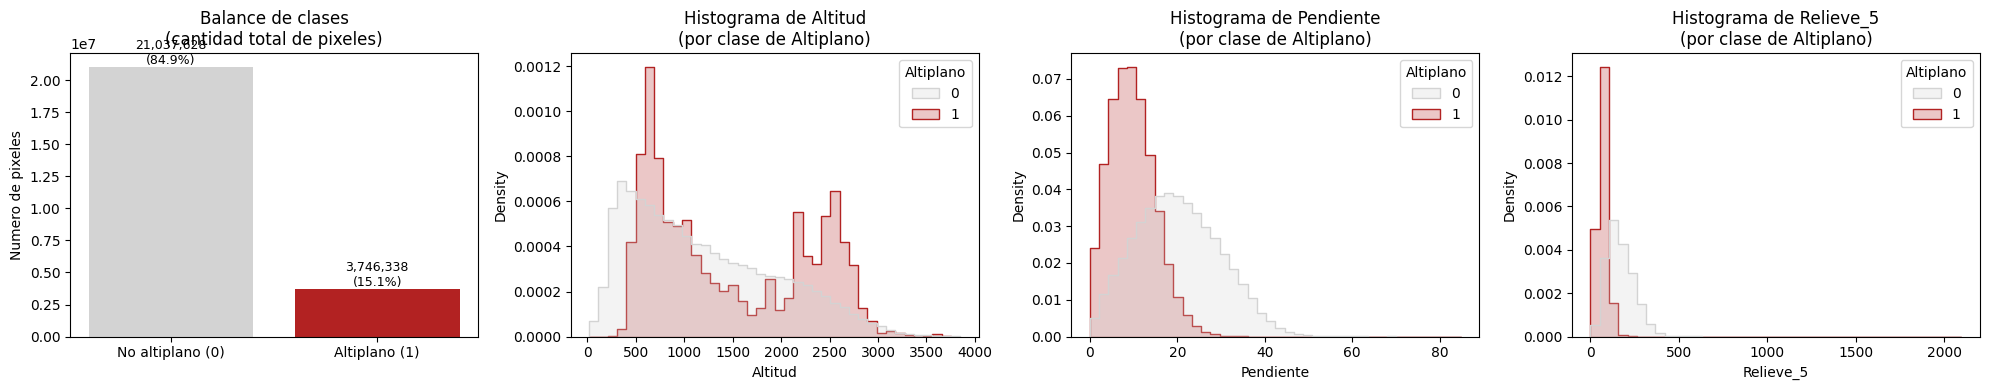

In [8]:
# .sample(): submuestra de 200.000 píxeles para los histogramas (dibujar 25M sería lentísimo).
muestra_para_histograma = tabla.sample(n=200_000, random_state=SEMILLA)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))  # 4 paneles en una fila

# Panel 1: conteo total por clase (poblacion completa, no la muestra)
ax0 = axes[0]
colores_clase = {0: "lightgray", 1: "firebrick"}
barras = ax0.bar(["No altiplano (0)", "Altiplano (1)"], [conteo[0], conteo[1]],
                  color=[colores_clase[0], colores_clase[1]])
for barra, valor in zip(barras, [conteo[0], conteo[1]]):   # anota el valor y % encima de cada barra
    ax0.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
              f"{valor:,}\n({100*valor/n_final_validos:.1f}%)", ha="center", va="bottom", fontsize=9)
ax0.set_title("Balance de clases\n(cantidad total de pixeles)")
ax0.set_ylabel("Numero de pixeles")

# Paneles 2-4: Altitud, Pendiente, Relieve_5 por clase (muestra de 200,000)
for ax, var in zip(axes[1:], ["Altitud", "Pendiente", "Relieve_5"]):
    # hue="Altiplano" dibuja una curva por clase; stat="density"+common_norm=False = cada clase
    # normalizada por separado (comparables aunque una clase tenga muchos más píxeles).
    sns.histplot(data=muestra_para_histograma, x=var, hue="Altiplano", bins=40,
                 palette=colores_clase, ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(f"Histograma de {var}\n(por clase de Altiplano)")

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_predictores.png"), dpi=150)
plt.show()

## [7] Matriz de correlación entre predictores

Se calcula sobre **toda la población de píxeles válidos** (no solo una muestra), ya que la
correlación es barata de calcular incluso con ~25 millones de filas.

**Ventajas / desventajas:**
- (+) Permite detectar a simple vista pares de variables muy correlacionadas.
- (-) La correlación por pares NO detecta redundancias que involucran a tres o más
  variables simultáneamente. Por eso se complementa con el VIF en la sección [8].


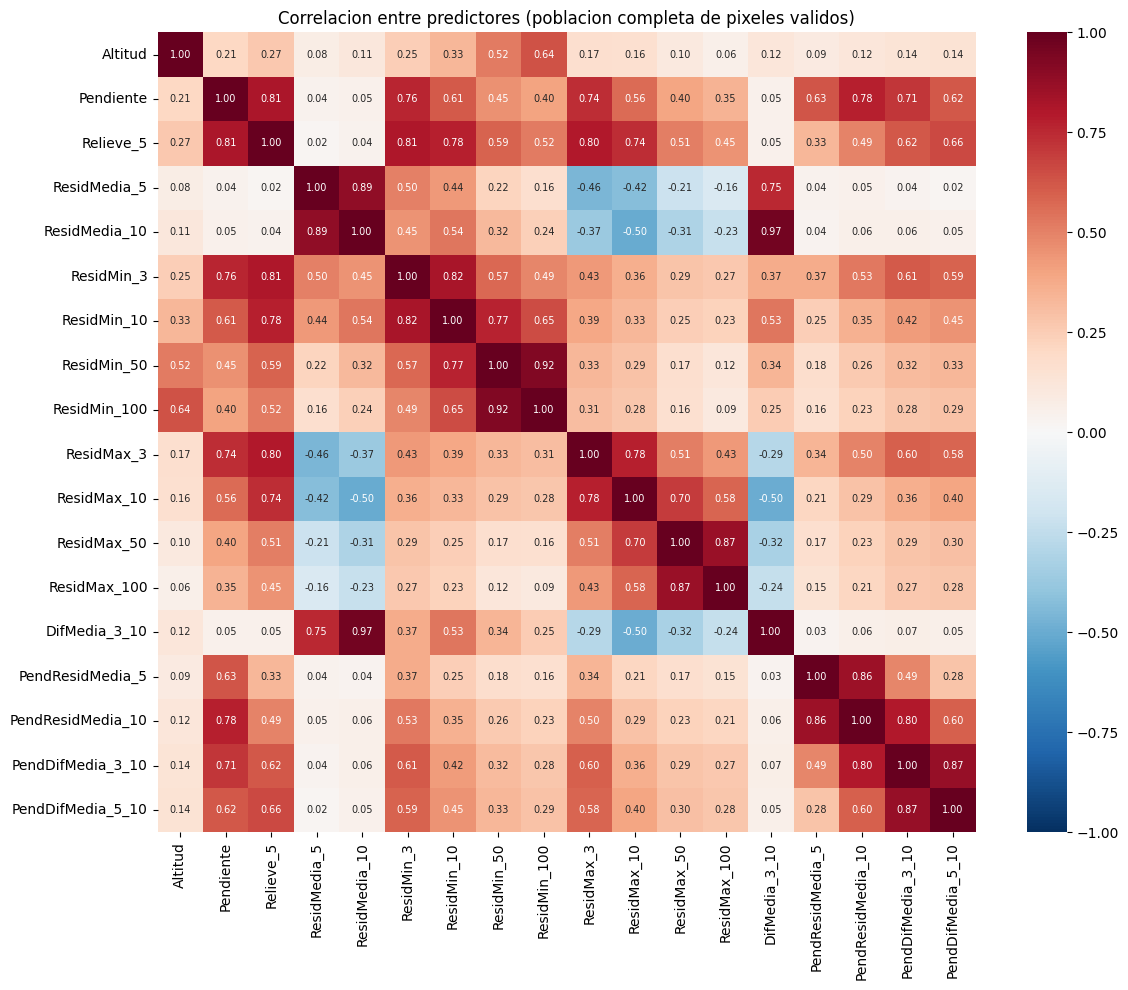

In [9]:
correlacion = tabla[variables_predictoras].corr()  # matriz de correlación (población completa, es barata)

plt.figure(figsize=(12, 10))
# heatmap anotado; annot_kws={"size":7} achica el número por ser una matriz 18x18.
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Correlacion entre predictores (poblacion completa de pixeles validos)")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_correlacion_predictores_raster.png"), dpi=150)
plt.show()

## [8] Factor de Inflación de Varianza (VIF): detectar y resolver colinealidad exacta

El VIF cuantifica cuánta varianza de una variable es explicada por las DEMÁS variables
predictoras. Se calcula sobre una muestra aleatoria de 50,000 píxeles (costoso con millones
de filas, ya que requiere una regresión lineal por cada variable contra todas las demás).


In [10]:
# VIF (Factor de Inflación de Varianza) sobre 50.000 píxeles: cuantifica colinealidad
# (cuánta varianza de una variable explican las demás). Es costoso, por eso se submuestrea.
muestra_vif = tabla[variables_predictoras].sample(n=50_000, random_state=SEMILLA)
X_vif = sm.add_constant(muestra_vif)   # add_constant agrega la columna de intercepto (requerida por el VIF)

vif_resultado = pd.DataFrame({
    "variable": X_vif.columns,
    # variance_inflation_factor(matriz, i) = VIF de la columna i (regresión de esa columna contra las otras).
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_resultado

,variable,VIF
0,const,8.119568
1,Altitud,1.795061
2,Pendiente,9.244856
3,Relieve_5,27.396079
4,ResidMedia_5,33.060844
5,ResidMedia_10,236.465238
6,ResidMin_3,14.161788
7,ResidMin_10,12.243578
8,ResidMin_50,10.787879
9,ResidMin_100,9.339161


**Hallazgo:** al calcular el VIF sobre el listado ORIGINAL de 21 capas (incluyendo
`Relieve_3`, `Relieve_10` y `DifMedia_5_10`), varias variables mostraban VIF **infinito**.
La causa es una identidad geomorfométrica exacta: `Relieve = ResidMax + ResidMin` para una
misma ventana móvil, y `DifMedia_5_10 = ResidMedia_5 - ResidMedia_10`. Por eso se excluyeron
esas tres variables (sección [4]). El resto de los VIF siguen siendo altos porque estas
variables son, por diseño, todas transformaciones de la misma superficie de elevación en
distintas escalas — se documenta como limitación del modelo (afecta la estabilidad de los
coeficientes individuales, no necesariamente la capacidad predictiva global).


## [9] Muestreo, división train/test y estandarización

Ajustar `statsmodels.Logit` sobre ~25 millones de filas sería innecesariamente lento para
una primera aproximación exploratoria, así que se toma una muestra aleatoria de
`N_MUESTRA=300,000`. La predicción final (sección [12]) sí se aplica sobre la totalidad de
los píxeles válidos. Partición 70/30 (entrenamiento/prueba) estratificada por la variable
respuesta.


In [11]:
muestra = tabla.sample(n=N_MUESTRA, random_state=SEMILLA)  # 300.000 píxeles para ajustar
X = muestra[variables_predictoras]   # predictores
y = muestra["Altiplano"]             # respuesta 0/1

print(f"Muestra para ajuste: {len(muestra):,} pixeles de {len(tabla):,} totales "
      f"({100*len(muestra)/len(tabla):.2f}% de la poblacion). Proporcion Altiplano=1: {y.mean()*100:.1f}%")

# Partición 70/30. stratify=y mantiene la misma proporción de Altiplano en train y test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEMILLA, stratify=y)

escalador = StandardScaler()
X_train_s = escalador.fit_transform(X_train)   # aprende media/desv en TRAIN y estandariza train
X_test_s = escalador.transform(X_test)         # aplica la MISMA media/desv a test (no re-aprende: evita fuga)
X_train_sm = sm.add_constant(X_train_s)        # agrega intercepto para statsmodels
X_test_sm = sm.add_constant(X_test_s)

print(f"Entrenamiento: {len(X_train):,} filas. Prueba: {len(X_test):,} filas.")

Muestra para ajuste: 300,000 pixeles de 24,783,966 totales (1.21% de la poblacion). Proporcion Altiplano=1: 15.1%
Entrenamiento: 210,000 filas. Prueba: 90,000 filas.


## [10] Función auxiliar: reporte de métricas y figura de confusión+ROC

Se define una función reutilizable para reportar métricas y graficar la matriz de confusión
(conteos + normalizada) + curva ROC, **enfocada en la clase Altiplano** (recall, precisión y
F1 de Altiplano se imprimen primero y más prominentes que los de "No altiplano", por
instrucción explícita del usuario). El mismo diseño se reutiliza en
`05_modelo_jerarquico_cordilleras_v2.ipynb` para que las figuras de ambos notebooks sean
directamente comparables.


In [12]:
def reportar_metricas_y_graficar(y_test, y_prob, nombre_modelo, nombre_archivo, umbral=0.5):
    '''Calcula metricas de clasificacion enfocadas en Altiplano=1, imprime un resumen tipo
    tabla, y grafica conteos + matriz normalizada + curva ROC. Devuelve (matriz_conf, auc,
    reporte_dict).
    '''
    y_pred = (y_prob >= umbral).astype(int)   # convierte probabilidad -> clase 0/1 según el umbral
    matriz_conf = confusion_matrix(y_test, y_pred, labels=[0, 1])   # [[VN,FP],[FN,VP]]
    # matriz normalizada por FILA (por clase real): cada fila suma 1 -> resalta el recall de cada clase.
    matriz_conf_norm = matriz_conf.astype(float) / matriz_conf.sum(axis=1, keepdims=True)
    # classification_report(output_dict=True) -> dict con precision/recall/f1 por clase.
    reporte = classification_report(y_test, y_pred, target_names=["No altiplano", "Altiplano"], output_dict=True)
    auc = roc_auc_score(y_test, y_prob)  # y_prob = P(Altiplano=1); pos_label=1 por defecto en roc_auc_score

    print(f"RESUMEN DE METRICAS -- {nombre_modelo}  (enfocado en la clase ALTIPLANO)")
    print(f"  Recall (Altiplano):     {reporte['Altiplano']['recall']:.3f}   "
          f"(de los pixeles que SI son altiplano, que fraccion detecta el modelo)")
    print(f"  Precision (Altiplano):  {reporte['Altiplano']['precision']:.3f}   "
          f"(de los pixeles predichos como altiplano, que fraccion lo es de verdad)")
    print(f"  F1-score (Altiplano):   {reporte['Altiplano']['f1-score']:.3f}")
    print(f"  AUC-ROC (positivo=Altiplano): {auc:.4f}")
    print(f"  --- referencia general (no el foco principal) ---")
    print(f"  Accuracy: {reporte['accuracy']:.4f}   "
          f"Recall/Precision No-altiplano: {reporte['No altiplano']['recall']:.3f} / {reporte['No altiplano']['precision']:.3f}")

    etiquetas = ["No altiplano", "Altiplano"]
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))   # 3 paneles: conteos, normalizada, ROC

    ax1.imshow(matriz_conf, cmap="Blues")   # panel 1: matriz de conteos brutos como imagen
    for i in range(2):
        for j in range(2):
            color = "white" if matriz_conf[i, j] > matriz_conf.max() * 0.5 else "black"
            ax1.text(j, i, f"{matriz_conf[i, j]:,}", ha="center", va="center", color=color)   # escribe cada conteo
    ax1.set_xticks([0, 1]); ax1.set_xticklabels(etiquetas)
    ax1.set_yticks([0, 1]); ax1.set_yticklabels(etiquetas)
    ax1.set_xlabel("Prediccion"); ax1.set_ylabel("Clase real")
    ax1.set_title("Conteos brutos")

    im2 = ax2.imshow(matriz_conf_norm, cmap="Blues", vmin=0, vmax=1)   # panel 2: matriz normalizada por clase
    for i in range(2):
        for j in range(2):
            color = "white" if matriz_conf_norm[i, j] > 0.5 else "black"
            ax2.text(j, i, f"{matriz_conf_norm[i, j]*100:.1f}%", ha="center", va="center", color=color)
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(etiquetas)
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(etiquetas)
    ax2.set_xlabel("Prediccion"); ax2.set_ylabel("Clase real")
    ax2.set_title("Normalizada por clase real\n(recall de Altiplano al mismo peso visual)")
    plt.colorbar(im2, ax=ax2, fraction=0.046, label="Proporcion dentro de la clase real")

    # panel 3: curva ROC. roc_curve devuelve (FPR, TPR, umbrales); pos_label=1 = Altiplano es la clase positiva.
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    ax3.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f} (positivo=Altiplano)")
    ax3.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")   # diagonal = clasificador al azar
    ax3.set_xlabel("Tasa de Falsos Positivos (FPR)")
    ax3.set_ylabel("Tasa de Verdaderos Positivos (TPR) -- Altiplano")
    ax3.set_title("Curva ROC (positivo = Altiplano)")
    ax3.legend(loc="lower right")

    fig.suptitle(nombre_modelo, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_FIGURAS, nombre_archivo), dpi=150)
    plt.show()

    return matriz_conf, auc, reporte   # devuelve resultados por si se necesitan después

## [11] Modelo interpretable: regresión logística con `statsmodels`

Se obtiene el resumen estadístico completo del modelo (coeficientes, significancia, Pseudo
R², prueba de razón de verosimilitud), igual que el ejemplo de susceptibilidad a
movimientos en masa del libro (`04_GLMPhyton`).

**Interpretación del Pseudo R²:** en una regresión logística no existe un R² en el sentido
clásico de OLS. El libro reporta el **Pseudo R² de McFadden** (`prsquared` en
`statsmodels`): valores de 0.2-0.4 ya se consideran un ajuste excelente en esta escala.


In [13]:
# sm.Logit(y, X).fit(disp=0): ajusta la regresión logística por máxima verosimilitud;
# disp=0 silencia el log de convergencia. .summary() = tabla estadística estilo libro.
modelo_logit = sm.Logit(y_train.values, X_train_sm).fit(disp=0)
print(modelo_logit.summary(xname=["const"] + variables_predictoras))   # xname pone los nombres reales de las variables

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               210000
Model:                          Logit   Df Residuals:                   209981
Method:                           MLE   Df Model:                           18
Date:                Fri, 17 Jul 2026   Pseudo R-squ.:                  0.5514
Time:                        05:51:21   Log-Likelihood:                -39948.
converged:                       True   LL-Null:                       -89056.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -5.1987      0.030   -174.019      0.000      -5.257      -5.140
Altitud               1.1472      0.012     99.596      0.000       1.125       1.170
Pendiente            -0.

**Advertencia detectada en la salida de `statsmodels` (importante):** *"Possibly complete
quasi-separation"* — para una fracción sustancial de píxeles, la combinación de predictores
permite clasificarlos con certeza casi perfecta. Es coherente con el AUC muy alto obtenido
más adelante, pero implica que los errores estándar de algunos coeficientes (y sus valores
p) dejan de ser totalmente confiables, aunque el modelo siga siendo útil para **predecir**.
Por eso las conclusiones se apoyan en las métricas de predicción (Pseudo R², AUC, matriz de
confusión) más que en la significancia individual de cada coeficiente.


In [14]:
print("AJUSTE DEL MODELO (statsmodels.Logit):")
print(f"  Pseudo R2 (McFadden):          {modelo_logit.prsquared:.4f}")   # pseudo-R² (0,2-0,4 ya es muy bueno)
print(f"  Log-Likelihood:                {modelo_logit.llf:.1f}")          # log-verosimilitud del modelo
print(f"  AIC:                           {modelo_logit.aic:.1f}")          # criterio de información de Akaike
print(f"  BIC:                           {modelo_logit.bic:.1f}")          # criterio bayesiano (penaliza más parámetros)

AJUSTE DEL MODELO (statsmodels.Logit):
  Pseudo R2 (McFadden):          0.5514
  Log-Likelihood:                -39948.3
  AIC:                           79934.6
  BIC:                           80129.5


## [12] Evaluación de clasificación (matriz de confusión, ROC, AUC)

Se verifica explícitamente `modelo_logit`'s predicciones producen $P(\text{Altiplano}=1)$
directamente (`statsmodels` siempre predice la media de la distribución, que para Binomial
es la probabilidad), y se aplica la función de la sección [10].


RESUMEN DE METRICAS -- Regresion logistica (GLM Binomial, enlace logit)  (enfocado en la clase ALTIPLANO)
  Recall (Altiplano):     0.645   (de los pixeles que SI son altiplano, que fraccion detecta el modelo)
  Precision (Altiplano):  0.741   (de los pixeles predichos como altiplano, que fraccion lo es de verdad)
  F1-score (Altiplano):   0.690
  AUC-ROC (positivo=Altiplano): 0.9522
  --- referencia general (no el foco principal) ---
  Accuracy: 0.9124   Recall/Precision No-altiplano: 0.960 / 0.938


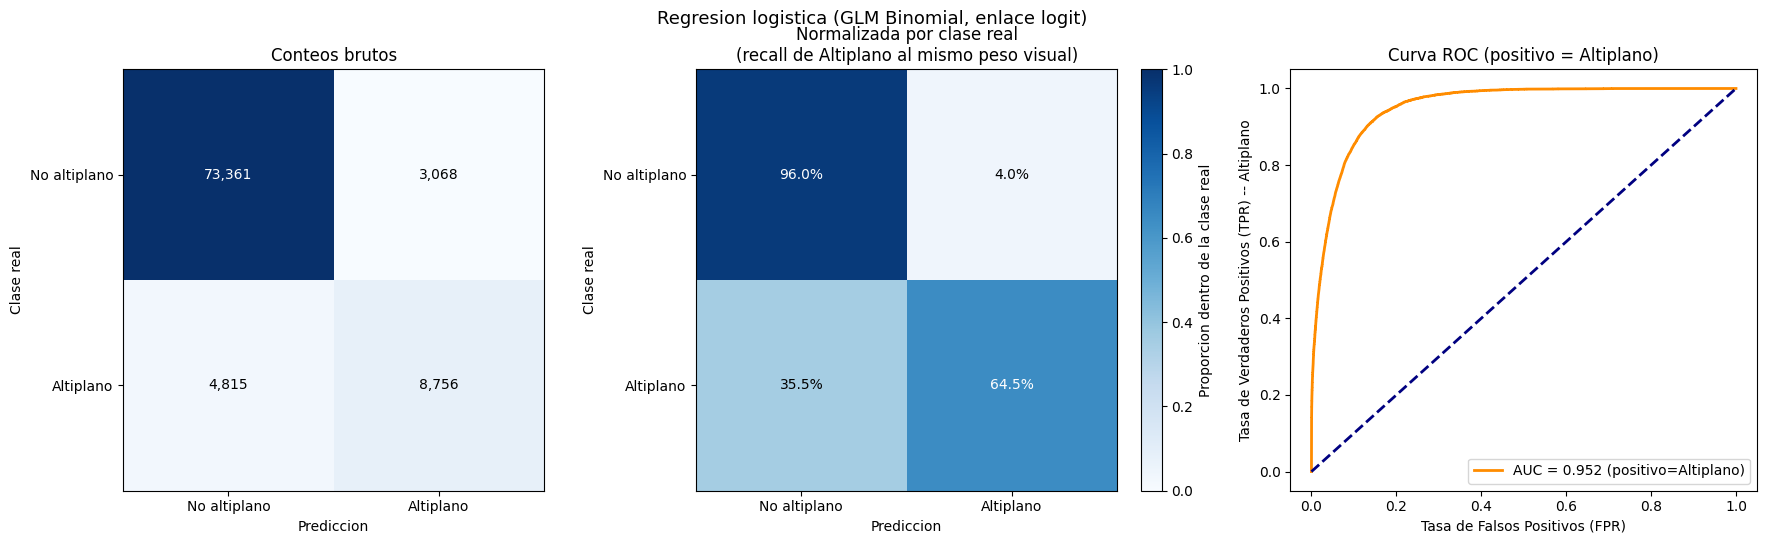

In [15]:
# .predict() sobre el test devuelve P(Altiplano=1) por píxel; se evalúa con la función auxiliar.
prob_test_logit = modelo_logit.predict(X_test_sm)
matriz_conf, auc, reporte = reportar_metricas_y_graficar(
    y_test, prob_test_logit, "Regresion logistica (GLM Binomial, enlace logit)", "02_matriz_confusion_roc.png")

## [13] Predicción sobre toda el área de estudio: mapa de probabilidad

Se aplica el modelo ajustado a **todos** los píxeles válidos del área de estudio, igual que
el "Mapa de Probabilidad de Movimiento en Masa" del notebook `04_GLMPhyton`.


In [16]:
t_pred = time.time()

# Predicción sobre TODOS los píxeles válidos (no solo la muestra) para armar el mapa completo.
X_todos = tabla[variables_predictoras]
X_todos_s = escalador.transform(X_todos)        # misma estandarización aprendida en train
X_todos_sm = sm.add_constant(X_todos_s)
prob_todos = modelo_logit.predict(X_todos_sm)   # probabilidad por píxel

print(f"Prediccion sobre {len(X_todos):,} pixeles en {time.time()-t_pred:.1f} s")

# Reconstruye la matriz 2D del mapa: NaN fuera del área, y la probabilidad en los píxeles válidos.
mapa_probabilidad = np.full(ref_shape, np.nan, dtype=np.float32)
mapa_probabilidad.ravel()[idx_validos] = prob_todos   # coloca cada prob en su píxel original

print(f"Rango de probabilidad predicha: {np.nanmin(mapa_probabilidad):.3f} - {np.nanmax(mapa_probabilidad):.3f}")

Prediccion sobre 24,783,966 pixeles en 3.6 s
Rango de probabilidad predicha: 0.000 - 0.998


**Comparación con los polígonos originales:** se superpone `Clusters.shp` (los 491
polígonos delimitados a mano) sobre el mapa de probabilidad, mostrando solo el borde para
no tapar el mapa de calor.


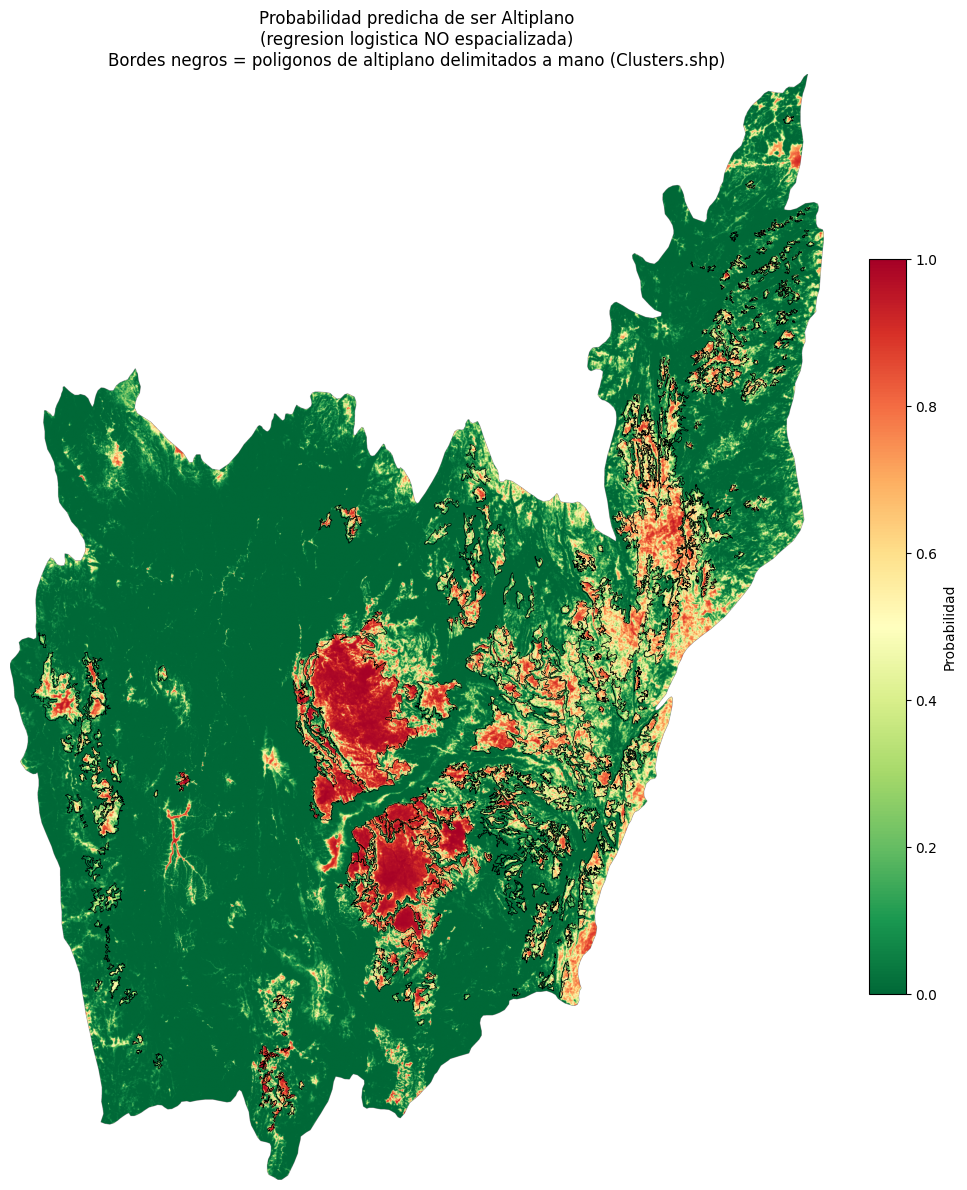

In [17]:
# Carga los 491 polígonos delimitados a mano (para superponer su borde sobre el mapa).
poligonos_originales = gpd.read_file(r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Clusters.shp")
if poligonos_originales.crs != ref_crs:
    poligonos_originales = poligonos_originales.to_crs(ref_crs)   # reproyecta si el CRS no coincide

# array_bounds -> (izq, abajo, der, arriba) en coordenadas geográficas, para ubicar la imagen en el mapa.
izquierda, abajo, derecha, arriba = array_bounds(ref_shape[0], ref_shape[1], ref_transform)

fig, ax = plt.subplots(figsize=(10, 12))
# imshow dibuja la matriz de probabilidad; extent la ancla a coordenadas reales; vmin/vmax fijan la escala 0-1.
im = ax.imshow(mapa_probabilidad, cmap="RdYlGn_r", vmin=0, vmax=1, extent=(izquierda, derecha, abajo, arriba))
poligonos_originales.boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)   # solo el borde
ax.set_title("Probabilidad predicha de ser Altiplano\n(regresion logistica NO espacializada)\n"
             "Bordes negros = poligonos de altiplano delimitados a mano (Clusters.shp)")
ax.set_axis_off()
plt.colorbar(im, ax=ax, label="Probabilidad", fraction=0.04)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "03_mapa_probabilidad_altiplano.png"), dpi=150)
plt.show()

### [13b] Versión cartográfica del mapa de probabilidad (plantilla con hillshade/norte/escala)

Misma figura de la sección [13], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`). Esta celda solo llama a la capa ya calculada
(`mapa_probabilidad`) — no repite ningún cálculo del análisis.

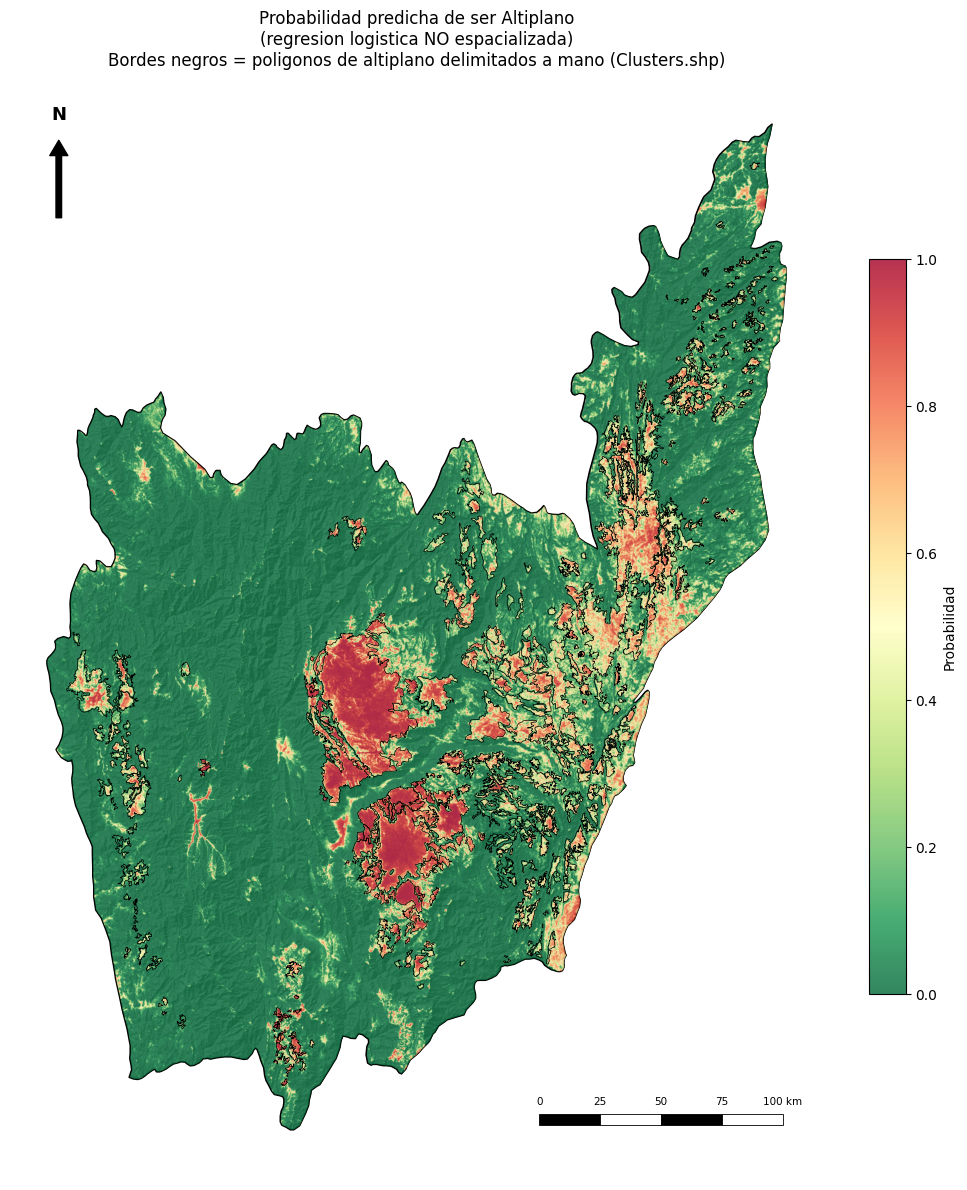

In [18]:
# Versión cartográfica del mismo mapa con la plantilla del proyecto (hillshade+norte+escala).
from plantilla_mapas import aplicar_plantilla_mapa, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "03_regresion_no_espacial_raster_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 12))
aplicar_plantilla_mapa(ax)   # dibuja hillshade + área de estudio + norte + escala como fondo

# alpha=0.8 (20% transparente) para dejar ver el hillshade; zorder controla el orden de dibujo (mayor = encima).
im = ax.imshow(mapa_probabilidad, cmap="RdYlGn_r", vmin=0, vmax=1,
               extent=(izquierda, derecha, abajo, arriba), alpha=0.8, zorder=5)
poligonos_originales.boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, zorder=6)
ax.set_title("Probabilidad predicha de ser Altiplano\n(regresion logistica NO espacializada)\n"
             "Bordes negros = poligonos de altiplano delimitados a mano (Clusters.shp)")
ax.set_axis_off()
plt.colorbar(im, ax=ax, label="Probabilidad", fraction=0.04)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "03_mapa_probabilidad_altiplano.png"), dpi=150)
plt.show()

## [14] Exportar el mapa de probabilidad como GeoTIFF

Se usa el sufijo `_v2` para no sobrescribir `Resultados\probabilidad_altiplano.tif` (capa
de la versión anterior).


In [19]:
# Perfil de escritura del GeoTIFF de salida: metadatos que definen cómo se guarda el ráster.
perfil_salida = {
    "driver": "GTiff",                    # formato GeoTIFF
    "height": ref_shape[0], "width": ref_shape[1], "count": 1,   # dimensiones y 1 sola banda
    "dtype": "float32",                   # tipo de dato (probabilidades decimales)
    "crs": ref_crs, "transform": ref_transform,   # georreferenciación (mismo CRS/grilla que el DEM)
    "nodata": np.nan,                     # NaN = fuera del área
    "compress": "lzw",                    # compresión sin pérdida para achicar el archivo
}

ruta_salida_raster = os.path.join(CARPETA_RESULTADOS, "probabilidad_altiplano_v2.tif")
# Abre el archivo en modo escritura ("w") con ese perfil y escribe la matriz en la banda 1.
with rasterio.open(ruta_salida_raster, "w", **perfil_salida) as dst:
    dst.write(mapa_probabilidad, 1)

print(f"Mapa de probabilidad guardado en: {ruta_salida_raster}")
print(f"\nTIEMPO TOTAL DEL NOTEBOOK: {time.time()-t_inicio:.1f} s")

Mapa de probabilidad guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\probabilidad_altiplano_v2.tif

TIEMPO TOTAL DEL NOTEBOOK: 92.4 s


## Conclusiones y siguientes pasos

- El modelo (18 predictores geomorfométricos, sin ninguna variable espacial) alcanza un
  Pseudo R² de McFadden y un AUC que indican una capacidad discriminante muy alta entre
  píxeles de altiplano y no-altiplano usando solo variables de forma del terreno.
- La matriz de correlación y, sobre todo, el VIF muestran que estas variables
  geomorfométricas están fuertemente correlacionadas entre sí (por construcción, todas
  derivan de la misma superficie de elevación en distintas ventanas); esto no invalida la
  predicción, pero sí advierte que los coeficientes individuales deben interpretarse con
  cautela.
- La matriz de confusión normalizada por fila deja explícito que el recall de Altiplano es
  bastante menor que el de "No altiplano" con el umbral por defecto (0.5) — un desbalance
  de clases que se retoma en `05_modelo_jerarquico_cordilleras_v2.ipynb` con
  `class_weight="balanced"`.
- **Limitación central de este notebook:** al ser una regresión NO espacializada, el
  modelo ignora que los píxeles de altiplano tienden a agruparse geográficamente. Ver
  `04_autocorrelacion_espacial_v2.ipynb` para el diagnóstico de autocorrelación espacial en
  los residuos de este mismo modelo.
